In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load and prepare data (from previous section)
iris = load_iris()
X = iris.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Here:
Each color represents a different cluster
The X markers represent the cluster centroids

# Choosing the Right Value of K

One practical challenge in K-Means is deciding:

- How many clusters should we use?

The algorithm requires us to specify K in advance, but often we do not know the best value beforehand. A common way to choose K is the **Elbow Method**.

## Elbow Method

The Elbow Method helps us determine the **optimal number of clusters (K)** in K-Means. It examines how the inertia or WCSS changes as we increase the number of clusters.
It works by:
- Running K-Means for different values of K  
- Computing **WCSS (inertia)** for each K  
- Plotting K vs WCSS  


> As **WCSS (inertia)** measures how tightly the data points are grouped around their centroids, lower inertia means points are closer to their centroids.

As we increase K:
- WCSS **decreases** (clusters become tighter)  
- But the improvement **slows down after a point** (becomes small).

We look for the point where the curve starts to bend like an elbow.

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251111115104211390/elbow_method.webp" width="500"/>
</p>

<p align="center">
<b>Figure:</b> Elbow method showing WCSS (inertia) vs number of clusters (K). The “elbow point” indicates the optimal number of clusters. Source: GeeksforGeeks

</p>

The point where the curve bends is called the **“elbow”**. This is typically the best choice for K. From the above figure, notice how the curve drops sharply at first, then flattens; the curve bends sharply at K = 4, then 4 may be a reasonable number of clusters. this change in slope is the “elbow.”


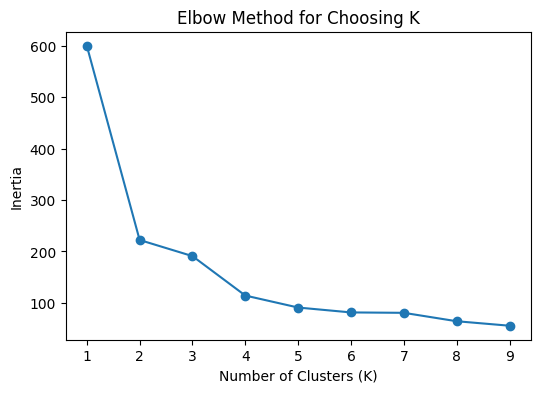

In [15]:
# Step 1: Compute inertia for different values of K
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Step 2: Plot the Elbow Curve

plt.figure(figsize=(6, 4))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.show()

# **Bonus Section**: Silhouette Score (Evaluating Clustering Quality)

While the Elbow Method helps us choose the number of clusters using WCSS, it does not always give a clear answer. To further evaluate clustering quality, we use: **Silhouette Score**

## What is Silhouette Score?

Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters.

For each point, it considers:

- **a(i)** = average distance to points in the same cluster (intra-cluster distance)  
- **b(i)** = average distance to points in the nearest neighboring cluster (inter-cluster distance)  

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

**Interpretation:** The score ranges from **-1 to 1**:

- **Close to +1** → well-clustered (far from other clusters)  
- **Close to 0** → overlapping clusters  
- **Close to -1** → wrongly assigned cluster  


The intuition is that, a good clustering should have:
- **Small intra-cluster** distance (points close together)  
- **Large inter-cluster** distance (clusters far apart)  

Silhouette score combines both ideas into a single metric.


## Using Silhouette Score to Choose K

Instead of only relying on the Elbow Method, we can:

- Compute silhouette score for different values of K  
- Choose the K with the **highest silhouette score**


<p align="center">
  <img src="https://miro.medium.com/v2/1*N3Xm52bELqrju_DWLqjyHg.jpeg" width="35%" style="margin-right:10px;"/>
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20250623153050051609/clustering.jpg" width="30%" style="margin-right:10px;"/>
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20250703152720891959/elbow_sil.png" width="25%"/>
</p>

<p align="center">
<b>Figure:</b> (a) Illustrating intra-cluster compactness and inter-cluster separation,
(b) clustering of data points into groups based on similarity,
(c) Elbow method and Silhouette score used to evaluate clustering quality.  
<sub>Sources: Medium; GeeksforGeeks</sub>
</p>

## Python Example

```python
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(range(2, 10), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()
```

## Summary of K-Means

K-Means is simple and powerful, but it comes with some assumptions:

**Strengths:**

- Easy to understand and implement
- Works well when clusters are compact and roughly spherical
- Fast for large datasets

**Limitation:s**
- Must choose K in advance
- Sensitive to initialization
- Can struggle when clusters have irregular shapes
- Distance-based, so scaling matters